# 02. Xây dựng Behavioral Representation  
**Mục tiêu** biến mỗi order thành một vector đặc trưng hành vi.  
**Đơn vị phân tích** chọn **order-level** thay vì user.  
Vector đặc trưng gồm 3 nhóm:
1. **Cơ cấu ngành hàng (department mix)** - tỷ trọng sản phẩm mỗi ngành hàng trong giỏ hàng (21 part)  
2. **Đặc điểm giỏ hàng** - kích thước giỏ hàng (log), có mua cuối tuần không,...  
3. **Nhịp thời gian trong ngày** - khung giờ mua

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

df_clean = pd.read_parquet('data/cleaned_items.parquet')
order_lvl = pd.read_parquet('data/order_level.parquet')
print(df_clean.shape, order_lvl.shape)

(1048574, 12) (103761, 8)


## 1. Cơ cấu ngành hàng

In [2]:
dept_counts = df_clean.pivot_table(index='order_id', columns='department', values='product_id',
                                    aggfunc='count', fill_value=0)
dept_share = dept_counts.div(dept_counts.sum(axis=1), axis=0)
dept_cols = list(dept_share.columns)
print('Số chiều department:', len(dept_cols))
dept_share.head()

Số chiều department: 21


department,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,...,household,international,meat seafood,missing,other,pantry,personal care,pets,produce,snacks
order_id,,,,,,,,,,,,,,,,,,,,,
11,0.0,0.0,0.0,0.000000,0.0,0.0,0.200000,0.000000,0.2,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.200000,0.000000,0.0,0.0,0.200000
64,0.0,0.0,0.0,0.400000,0.0,0.0,0.000000,0.200000,0.0,0.0,...,0.200000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000
110,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.200000,0.0,0.0,...,0.000000,0.0,0.100000,0.0,0.0,0.000000,0.100000,0.0,0.6,0.000000
192,0.0,0.0,0.0,0.000000,0.0,0.0,0.066667,0.200000,0.0,0.0,...,0.066667,0.0,0.066667,0.0,0.0,0.066667,0.066667,0.0,0.2,0.266667
205,0.0,0.0,0.0,0.666667,0.0,0.0,0.000000,0.333333,0.0,0.0,...,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000


# 2. Ghép đặc trung và feature bổ sung

In [6]:
feat = order_lvl.set_index('order_id').join(dept_share)

feat['weekend'] = feat['order_dow'].isin([0, 6]).astype(int)  # 0=CN, 6=T7
feat['start_week'] = (feat['order_dow'] == 1).astype(int)
feat['is_first_order'] = feat['days_since_prior_order'].isna().astype(int)
feat['log_days_prior'] = np.log1p(feat['days_since_prior_order'].fillna(feat['days_since_prior_order'].median()))
feat['log_basket'] = np.log1p(feat['basket_size'])

feat['hour_bucket'] = pd.cut(
    feat['order_hour_of_day'],
    bins=[-1, 5, 9, 13, 17, 21, 24],
    labels=[
        'night',       # 0-5
        'morning',     # 6-9
        'noon',        # 10-13
        'afternoon',   # 14-17
        'evening',     # 18-21
        'late_evening' # 22-23
    ]
)
hb = pd.get_dummies(feat['hour_bucket'], prefix='hb').astype(int)
feat = pd.concat([feat, hb], axis=1)
hb_cols = list(hb.columns)

print('Tổng số cột feature:', feat.shape[1])
feat[dept_cols + ['log_basket', 'weekend'] + hb_cols].head()

Tổng số cột feature: 40


,alcohol,babies,bakery,beverages,breakfast,bulk,canned goods,dairy eggs,deli,dry goods pasta,...,produce,snacks,log_basket,weekend,hb_night,hb_morning,hb_noon,hb_afternoon,hb_evening,hb_late_evening
order_id,,,,,,,,,,,,,,,,,,,,,
11,0.0,0.0,0.0,0.000000,0.0,0.0,0.200000,0.000000,0.2,0.0,...,0.0,0.200000,1.791759,0,0,0,0,0,1,0
64,0.0,0.0,0.0,0.400000,0.0,0.0,0.000000,0.200000,0.0,0.0,...,0.0,0.000000,1.791759,1,0,0,0,1,0,0
110,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.200000,0.0,0.0,...,0.6,0.000000,2.397895,1,0,0,0,1,0,0
192,0.0,0.0,0.0,0.000000,0.0,0.0,0.066667,0.200000,0.0,0.0,...,0.2,0.266667,2.772589,0,0,0,0,1,0,0
205,0.0,0.0,0.0,0.666667,0.0,0.0,0.000000,0.333333,0.0,0.0,...,0.0,0.000000,1.386294,0,0,0,0,1,0,0


## 3. Visualize behavioral representation  
#### 3.1 Heatmap tương quan giữa các ngành hàng

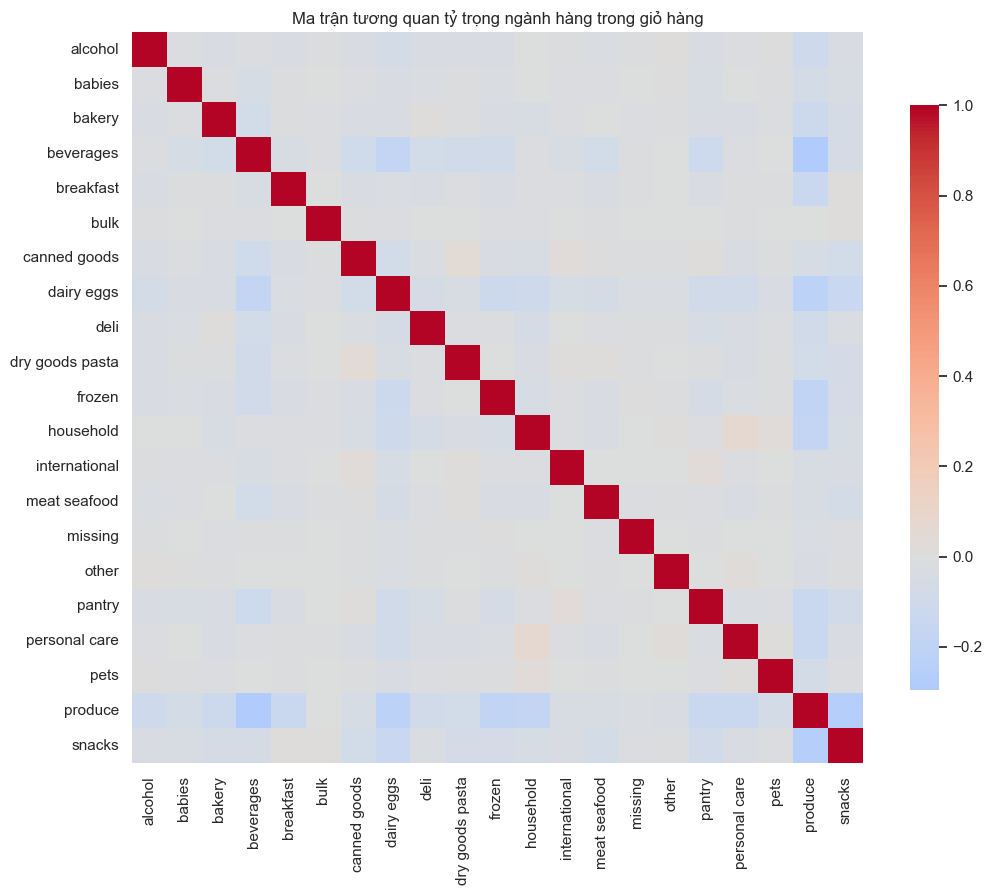

In [4]:
corr = feat[dept_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'shrink':0.8})
ax.set_title('Ma trận tương quan tỷ trọng ngành hàng trong giỏ hàng')
plt.tight_layout()
plt.show()

#### 3.2 Phân phối các feature

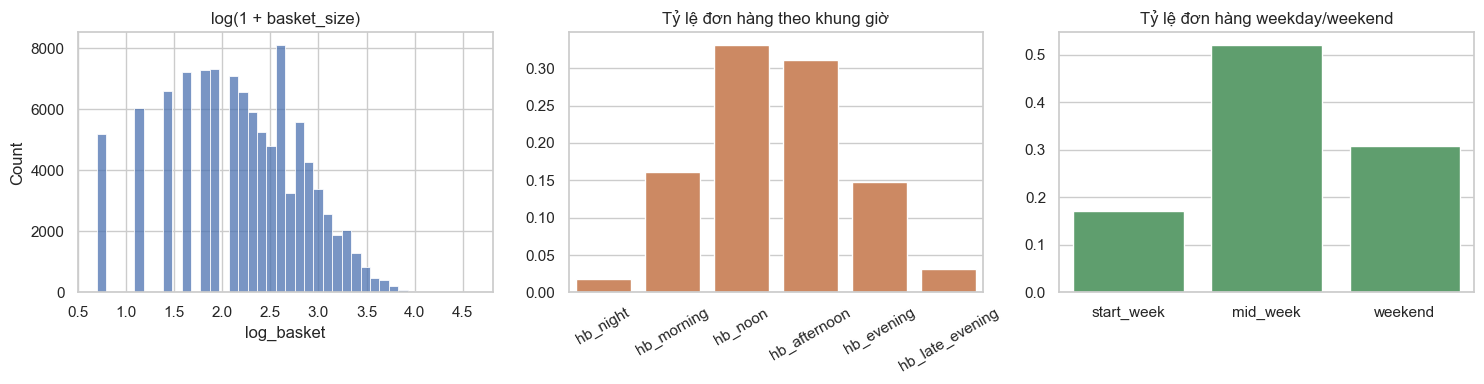

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(feat['log_basket'], bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('log(1 + basket_size)')
sns.barplot(x=hb_cols, y=[feat[c].mean() for c in hb_cols], ax=axes[1], color='#DD8452')
axes[1].set_title('Tỷ lệ đơn hàng theo khung giờ')
axes[1].tick_params(axis='x', rotation=30)

axes[2].set_title('Tỷ lệ đơn hàng theo nhóm ngày')
start_week_rate = (feat['order_dow'] == 1).mean()
weekend_rate = feat['order_dow'].isin([0, 6]).mean()
mid_week_rate = feat['order_dow'].isin([2, 3, 4, 5]).mean()

sns.barplot(
    x=['start_week', 'mid_week', 'weekend'],
    y=[start_week_rate, mid_week_rate, weekend_rate],
    ax=axes[2],
    color='#55A868'
)

axes[2].set_title('Tỷ lệ đơn hàng weekday/weekend')
plt.tight_layout()
plt.show()

=> phần lớn đơn hàng diễn ra vào noon/afternoon, tỷ lệ đơn cuối tuần và đầu tuần chiếm 50% tổng số đơn

# 4. Chuẩn hóa

In [9]:
from sklearn.preprocessing import StandardScaler

cluster_feature_cols = dept_cols + ['log_basket', 'weekend'] + hb_cols
X = feat[cluster_feature_cols].fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Ma trận đặc trưng dùng để clustering:', X_scaled.shape)
print('Số chiều:', len(cluster_feature_cols))
print(cluster_feature_cols)

Ma trận đặc trưng dùng để clustering: (103761, 29)
Số chiều: 29
['alcohol', 'babies', 'bakery', 'beverages', 'breakfast', 'bulk', 'canned goods', 'dairy eggs', 'deli', 'dry goods pasta', 'frozen', 'household', 'international', 'meat seafood', 'missing', 'other', 'pantry', 'personal care', 'pets', 'produce', 'snacks', 'log_basket', 'weekend', 'hb_night', 'hb_morning', 'hb_noon', 'hb_afternoon', 'hb_evening', 'hb_late_evening']


In [10]:
import json, os
os.makedirs('data', exist_ok=True)

feat_out = feat.reset_index()  # order_id trở lại thành cột
feat_out.to_parquet('data/order_features.parquet', index=False)

np.save('data/X_scaled.npy', X_scaled)

with open('data/feature_cols.json', 'w') as f:
    json.dump({
        'cluster_feature_cols': cluster_feature_cols,
        'dept_cols': dept_cols,
        'hb_cols': hb_cols,
        'lifecycle_cols': ['reorder_rate', 'order_number', 'is_first_order', 'log_days_prior'],
    }, f, indent=2)

print('Đã lưu:')
print(' - data/order_features.parquet  :', feat_out.shape)
print(' - data/X_scaled.npy            :', X_scaled.shape)
print(' - data/feature_cols.json')

Đã lưu:
 - data/order_features.parquet  : (103761, 41)
 - data/X_scaled.npy            : (103761, 29)
 - data/feature_cols.json
